In [1]:
def lr_to_class(left, right):
    # 0 = Left, 1 = None, 2 = Right
    if (left == 0 and right == 0) or (left == 1 and right == 1):
        return 1  # None
    if left == 1 and right == 0:
        return 0  # Left
    if left == 0 and right == 1:
        return 2  # Right
    return 1

import os
import csv
import numpy as np
import tensorflow as tf


class FrameCSVSequence(tf.keras.utils.Sequence):
    """
    Keras Sequence that reads frames + labels from a CSV file.
    """

    def __init__(
        self,
        csv_path,
        frames_dir,
        batch_size=32,
        shuffle=True,
        image_size=(224, 224),
    ):
        self.csv_path = csv_path
        self.frames_dir = frames_dir
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.image_size = image_size

        self.samples = []
        with open(csv_path, "r", newline="") as f:
            reader = csv.DictReader(f)
            for r in reader:
                fname = r["filename"]
                left = int(r["left"])
                right = int(r["right"])
                label = lr_to_class(left, right)
                self.samples.append((fname, label))

        self.indices = np.arange(len(self.samples))
        self.on_epoch_end()

        print(f"Loaded {len(self.samples)} samples")

    def __len__(self):
        return int(np.ceil(len(self.samples) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        batch_x = []
        batch_y = []

        for i in batch_idx:
            fname, label = self.samples[i]
            img_path = os.path.join(self.frames_dir, fname)

            # Load image
            img = tf.keras.utils.load_img(
                img_path,
                target_size=self.image_size,
            )
            img = tf.keras.utils.img_to_array(img)
            img = img / 255.0  # normalize

            batch_x.append(img)
            batch_y.append(label)

        return np.array(batch_x, dtype=np.float32), np.array(batch_y, dtype=np.int64)
    


In [2]:
import os
import csv
import numpy as np
import tensorflow as tf


def lr_to_class(left, right):
    # 0 = Left, 1 = None, 2 = Right
    if (left == 0 and right == 0) or (left == 1 and right == 1):
        return 1
    if left == 1 and right == 0:
        return 0
    if left == 0 and right == 1:
        return 2
    return 1


class FrameCSVSequence(tf.keras.utils.Sequence):
    """
    Keras Sequence that reads frames + labels from a CSV file
    and optionally masks out rectangular ROIs (e.g. HUD arrows).
    """

    def __init__(
        self,
        csv_path,
        frames_dir,
        batch_size=32,
        shuffle=True,
        image_size=(224, 224),
        mask_boxes=None,  # [(xmin,ymin,xmax,ymax), ...]
        mask_value=0.0,   # value to fill in normalized space [0,1]
    ):
        self.csv_path = csv_path
        self.frames_dir = frames_dir
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.image_size = image_size
        self.mask_boxes = mask_boxes or []
        self.mask_value = float(mask_value)

        self.samples = []
        with open(csv_path, "r", newline="") as f:
            reader = csv.DictReader(f)
            for r in reader:
                fname = r["filename"]
                left = int(r["left"])
                right = int(r["right"])
                label = lr_to_class(left, right)
                self.samples.append((fname, label))

        self.indices = np.arange(len(self.samples))
        self.on_epoch_end()
        print(f"Loaded {len(self.samples)} samples")

    def __len__(self):
        return int(np.ceil(len(self.samples) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def _apply_masks(self, img):
        """
        img: float32 (H,W,3) in [0,1]
        mask_boxes coords assumed in resized image pixel coords.
        """
        h, w = img.shape[:2]
        for (xmin, ymin, xmax, ymax) in self.mask_boxes:
            # clamp to image boundaries
            xmin = max(0, min(int(xmin), w))
            xmax = max(0, min(int(xmax), w))
            ymin = max(0, min(int(ymin), h))
            ymax = max(0, min(int(ymax), h))

            if xmax > xmin and ymax > ymin:
                img[ymin:ymax, xmin:xmax, :] = self.mask_value
        return img

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        batch_x = []
        batch_y = []

        for i in batch_idx:
            fname, label = self.samples[i]
            img_path = os.path.join(self.frames_dir, fname)

            img = tf.keras.utils.load_img(img_path, target_size=self.image_size)
            img = tf.keras.utils.img_to_array(img).astype(np.float32)
            img = img / 255.0  # normalize to [0,1]

            if self.mask_boxes:
                img = self._apply_masks(img)

            batch_x.append(img)
            batch_y.append(label)

        return np.array(batch_x, dtype=np.float32), np.array(batch_y, dtype=np.int64)



In [3]:
import os
import csv
import random
import numpy as np
import tensorflow as tf


def lr_to_class(left, right):
    # 0 = Left, 1 = None, 2 = Right
    if (left == 0 and right == 0) or (left == 1 and right == 1):
        return 1
    if left == 1 and right == 0:
        return 0
    if left == 0 and right == 1:
        return 2
    return 1


class FrameCSVSequence(tf.keras.utils.Sequence):
    """
    Keras Sequence that:
    - keeps ALL Left and Right samples
    - randomly samples up to max_none_per_epoch None samples per epoch
    """

    def __init__(
        self,
        csv_path,
        frames_dir,
        batch_size=32,
        shuffle=True,
        image_size=(224, 224),
        max_none_per_epoch=20000,
        mask_boxes=None,
        mask_value=0.0,
        seed=42,
    ):
        self.csv_path = csv_path
        self.frames_dir = frames_dir
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.image_size = image_size
        self.max_none_per_epoch = max_none_per_epoch
        self.mask_boxes = mask_boxes or []
        self.mask_value = float(mask_value)
        self.seed = seed
        self.epoch = 0

        # Load and split samples
        self.left_samples = []
        self.right_samples = []
        self.none_samples = []

        with open(csv_path, "r", newline="") as f:
            reader = csv.DictReader(f)
            for r in reader:
                fname = r["filename"]
                left = int(r["left"])
                right = int(r["right"])
                cls = lr_to_class(left, right)

                if cls == 0:
                    self.left_samples.append((fname, cls))
                elif cls == 2:
                    self.right_samples.append((fname, cls))
                else:
                    self.none_samples.append((fname, cls))

        print(
            f"Loaded CSV: "
            f"Left={len(self.left_samples)}, "
            f"None={len(self.none_samples)}, "
            f"Right={len(self.right_samples)}"
        )

        self._resample()

    # ---------- core mechanics ----------

    def _resample(self):
        rng = random.Random(self.seed + self.epoch)

        if len(self.none_samples) > self.max_none_per_epoch:
            none_subset = rng.sample(self.none_samples, self.max_none_per_epoch)
        else:
            none_subset = list(self.none_samples)

        self.active_samples = (
            self.left_samples + self.right_samples + none_subset
        )

        if self.shuffle:
            rng.shuffle(self.active_samples)

    def on_epoch_end(self):
        self.epoch += 1
        self._resample()

    def __len__(self):
        return int(np.ceil(len(self.active_samples) / self.batch_size))

    # ---------- masking ----------

    def _apply_masks(self, img):
        h, w = img.shape[:2]
        for (xmin, ymin, xmax, ymax) in self.mask_boxes:
            xmin = max(0, min(int(xmin), w))
            xmax = max(0, min(int(xmax), w))
            ymin = max(0, min(int(ymin), h))
            ymax = max(0, min(int(ymax), h))
            if xmax > xmin and ymax > ymin:
                img[ymin:ymax, xmin:xmax, :] = self.mask_value
        return img

    # ---------- batch access ----------

    def __getitem__(self, idx):
        batch = self.active_samples[
            idx * self.batch_size:(idx + 1) * self.batch_size
        ]

        batch_x = []
        batch_y = []

        for fname, label in batch:
            img_path = os.path.join(self.frames_dir, fname)

            img = tf.keras.utils.load_img(img_path, target_size=self.image_size)
            img = tf.keras.utils.img_to_array(img).astype(np.float32)
            img /= 255.0

            if self.mask_boxes:
                img = self._apply_masks(img)

            batch_x.append(img)
            batch_y.append(label)

        return np.array(batch_x, dtype=np.float32), np.array(batch_y, dtype=np.int64)


In [4]:
train_csv_path = r"D:\Data\Game Dataset\train_data\az_recorder_20260103_125453s_GamePlay_224x224_controls_extracted.csv"
train_frames_dir = r"D:\Data\Game Dataset\train_data\az_recorder_20260103_125453s_GamePlay_224x224"
train_csv_path2 = r"D:\Data\Game Dataset\train_data\az_recorder_20251231_165942_GamePlay_224x224_controls_extracted.csv"
train_frames_dir2 = r"D:\Data\Game Dataset\train_data\az_recorder_20251231_165942_GamePlay_224x224"
val_csv_path = r"D:\Data\Game Dataset\train_data\az_recorder_20260103_213242_GamePlay_224x224_controls_extracted.csv"
val_frames_dir = r"D:\Data\Game Dataset\train_data\az_recorder_20260103_213242_GamePlay_224x224"
image_size = (224, 224)
batch_size = 32

mask_boxes = [
    (2, 103, 58, 147),      # example left HUD region
    (165, 103, 221, 147),   # example right HUD region
]
train_gen = FrameCSVSequence(
    csv_path=train_csv_path,
    frames_dir=train_frames_dir,
    batch_size=batch_size,
    max_none_per_epoch=0,
    mask_boxes=mask_boxes,
    shuffle=True,
    image_size=image_size
)

train_gen2 = FrameCSVSequence(
    csv_path=train_csv_path2,
    frames_dir=train_frames_dir2,
    batch_size=batch_size,
    max_none_per_epoch=0,
    mask_boxes=mask_boxes,
    shuffle=True,
    image_size=image_size
)

val_gen =  FrameCSVSequence(
    csv_path=val_csv_path,
    frames_dir=val_frames_dir,
    batch_size=batch_size,
    max_none_per_epoch=0,
    mask_boxes=mask_boxes,
    shuffle=True,
    image_size=image_size
)

Loaded CSV: Left=16107, None=84781, Right=15108
Loaded CSV: Left=34857, None=169932, Right=33234
Loaded CSV: Left=11593, None=59435, Right=9550


In [6]:
import matplotlib.pyplot as plt
import numpy as np


def visualize_from_datagen(datagen, class_names, n=4):
    """
    Visualize `n` images from a Keras Sequence datagen.

    Args:
        datagen: FrameCSVSequence instance
        class_names: ["Left", "None", "Right"]
        n: number of images to display (default=4)
    """

    # Pick a random batch
    batch_idx = np.random.randint(0, len(datagen))
    x, y = datagen[batch_idx]

    n = min(n, len(x))
    plt.figure(figsize=(12, 6))

    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(x[i])
        plt.axis("off")
        plt.title(f"Label: {class_names[int(y[i])]}")

    plt.tight_layout()
    plt.show()


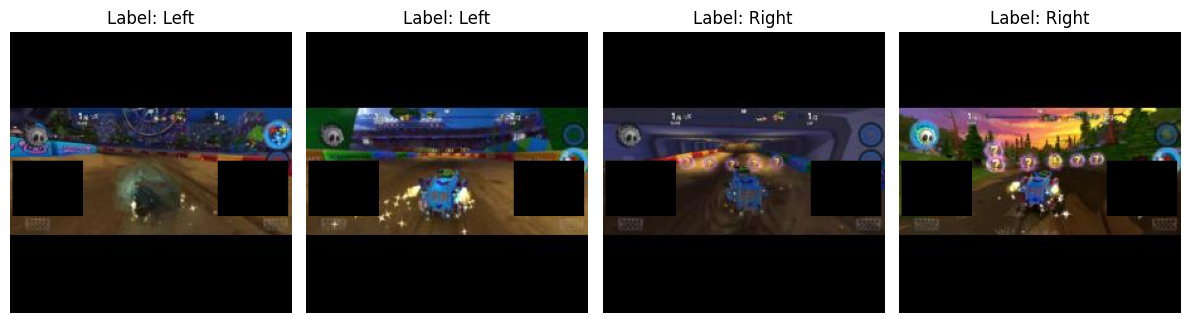

In [69]:
visualize_from_datagen(
    datagen=train_gen,
    class_names=["Left", "None", "Right"],
    n=4,
)

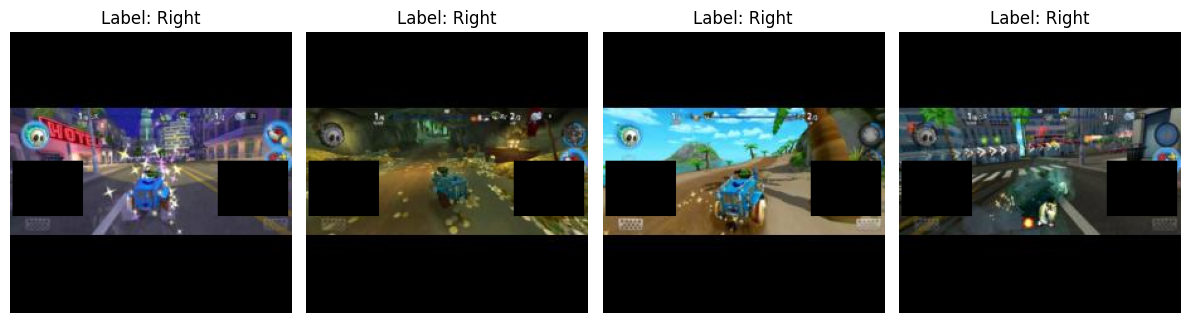

In [49]:
visualize_from_datagen(
    datagen=train_gen2,
    class_names=["Left", "None", "Right"],
    n=4,
)

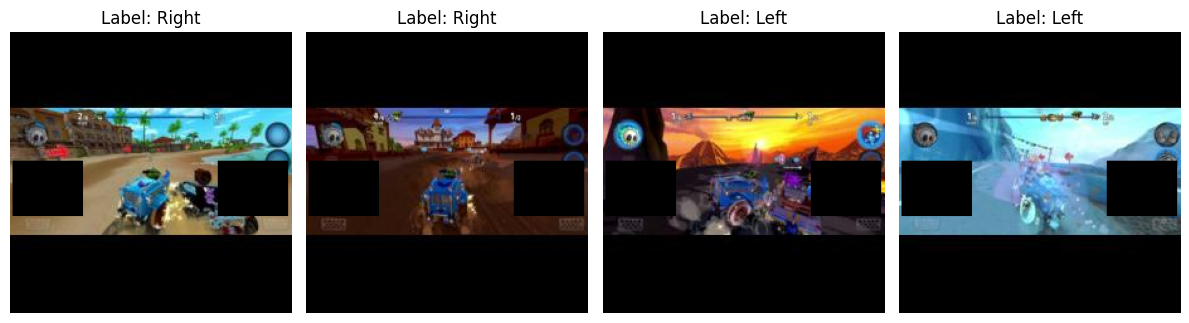

In [70]:
visualize_from_datagen(
    datagen=val_gen,
    class_names=["Left", "None", "Right"],
    n=4,
)


In [43]:
import tensorflow as tf


def build_single_frame_cnn_classifier(
    input_shape=(224, 224, 3),
    num_classes=3,
    dropout=0.2,
):
    """
    Single-frame CNN classifier in TensorFlow/Keras.
    - Input: RGB frame (224,224,3)
    - Output: logits for [Left, None, Right] (num_classes=3)
    - Normalization expected outside the model (divide by 255) or use Rescaling layer below.
    """

    inputs = tf.keras.Input(shape=input_shape)

    # Normalize to [0,1] inside the model (you can remove this if you already divide by 255)
    x = tf.keras.layers.Rescaling(1.0 / 255.0)(inputs)

    # Block 1
    x = tf.keras.layers.Conv2D(32, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPool2D(pool_size=2)(x)  # 112x112

    # Block 2
    x = tf.keras.layers.Conv2D(64, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPool2D(pool_size=2)(x)  # 56x56

    # Block 3
    x = tf.keras.layers.Conv2D(128, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPool2D(pool_size=2)(x)  # 28x28

    # Block 4
    x = tf.keras.layers.Conv2D(256, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPool2D(pool_size=2)(x)  # 14x14

    # Block 5
    x = tf.keras.layers.Conv2D(256, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPool2D(pool_size=2)(x)  # 7x7

    # Head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)  # (256,)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(dropout)(x)

    # Logits (no softmax here; use SparseCategoricalCrossentropy(from_logits=True))
    logits = tf.keras.layers.Dense(num_classes)(x)

    model = tf.keras.Model(inputs=inputs, outputs=logits, name="single_frame_cnn")
    return model


# Example usage:
model = build_single_frame_cnn_classifier(input_shape=(224, 224, 3), num_classes=3)
model.summary()


Model: "single_frame_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 rescaling_1 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 conv2d_5 (Conv2D)           (None, 224, 224, 32)      896       
                                                                 
 batch_normalization_5 (Batc  (None, 224, 224, 32)     128       
 hNormalization)                                                 
                                                                 
 re_lu_5 (ReLU)              (None, 224, 224, 32)      0         
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 112, 112, 32)     0         
 2D)                                              

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="acc"),
    ],
)


In [19]:
model.fit(train_gen2, validation_data=val_gen,epochs=1)

2128/2128 [==============================] - 884s 415ms/step - loss: 0.0883 - acc: 0.9673 - val_loss: 2.9383 - val_acc: 0.5483


In [29]:
model.fit(train_gen, validation_data=val_gen,epochs=1)


976/976 [==============================] - 483s 495ms/step - loss: 0.0081 - acc: 0.9977 - val_loss: 1.2894 - val_acc: 0.7208


In [17]:
model.fit(train_gen2, validation_data=val_gen,epochs=1)

2128/2128 [==============================] - 375s 176ms/step - loss: 0.1868 - acc: 0.9263 - val_loss: 0.8668 - val_acc: 0.4996


In [18]:
model.fit(train_gen, validation_data=val_gen,epochs=1)

976/976 [==============================] - 66s 68ms/step - loss: 0.0099 - acc: 0.9976 - val_loss: 1.1097 - val_acc: 0.7227


In [10]:
model_save_path = r"game_ai_agent_cnn_v1"

In [ ]:
# save the trained model
model.save(model_save_path)

INFO:tensorflow:Assets written to: game_ai_agent_cnn_v1\assets


INFO:tensorflow:Assets written to: game_ai_agent_cnn_v1\assets


In [12]:
# load the trained model
model = tf.keras.models.load_model(model_save_path)

In [13]:
model.summary()

Model: "single_frame_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 rescaling_1 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 conv2d_5 (Conv2D)           (None, 224, 224, 32)      896       
                                                                 
 batch_normalization_5 (Batc  (None, 224, 224, 32)     128       
 hNormalization)                                                 
                                                                 
 re_lu_5 (ReLU)              (None, 224, 224, 32)      0         
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 112, 112, 32)     0         
 2D)                                              

In [56]:
import numpy as np
import tensorflow as tf

def prediction_distribution(model, gen, num_batches=50):
    counts = np.zeros(3, dtype=int)
    gt_counts = np.zeros(3, dtype=int)

    for i in range(min(num_batches, len(gen))):
        x, y = gen[i]
        logits = model.predict(x, verbose=0)
        preds = np.argmax(tf.nn.softmax(logits, axis=-1).numpy(), axis=1)

        for k in range(3):
            counts[k] += np.sum(preds == k)
            gt_counts[k] += np.sum(y == k)

    return gt_counts, counts

gt, pred = prediction_distribution(model, train_gen, num_batches=100)
print("GT counts   (Left,None,Right):", gt)
print("Pred counts (Left,None,Right):", pred)


GT counts   (Left,None,Right): [1713    0 1487]
Pred counts (Left,None,Right): [1699    0 1501]


In [144]:
from collections import Counter
import numpy as np


def compute_gt_stats_from_datagen(datagen, class_names):
    """
    Compute ground-truth class statistics over the entire Keras datagen.

    Args:
        datagen: FrameCSVSequence
        class_names: ["Left", "None", "Right"]

    Returns:
        dict with counts and percentages
    """

    counter = Counter()
    total = 0

    for i in range(len(datagen)):
        _, y = datagen[i]
        y = y.tolist()
        counter.update(y)
        total += len(y)

    stats = {}
    for k, name in enumerate(class_names):
        count = counter.get(k, 0)
        pct = 100.0 * count / total if total > 0 else 0.0
        stats[name] = {
            "count": count,
            "percent": pct,
        }

    print("Ground-truth distribution (entire datagen):")
    for name, v in stats.items():
        print(f"{name:>5}: {v['count']:>8}  ({v['percent']:.2f}%)")

    print(f"\nTotal samples: {total}")

    return stats


In [ ]:
class_names = ["Left", "None", "Right"]

stats = compute_gt_stats_from_datagen(
    datagen=train_gen,
    class_names=class_names,
)


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


def predict_and_visualize_from_datagen(
    model,
    datagen,
    class_names,
    n=4,
):
    """
    Predict and visualize `n` samples from a Keras Sequence datagen.

    Shows:
      - image
      - ground truth label
      - predicted label
      - confidence

    Args:
        model: trained tf.keras.Model
        datagen: FrameCSVSequence
        class_names: ["Left", "None", "Right"]
        n: number of samples to show (default=4)
    """

    # Pick a random batch
    batch_idx = np.random.randint(0, len(datagen))
    x, y = datagen[batch_idx]

    # Limit to available batch size
    n = min(n, x.shape[0])

    # Run prediction
    logits = model.predict(x[:n], verbose=0)
    probs = tf.nn.softmax(logits, axis=-1).numpy()
    print(probs)
    preds = np.argmax(probs, axis=1)

    plt.figure(figsize=(12, 6))

    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(x[i])
        plt.axis("off")

        gt = class_names[int(y[i])]
        pred = class_names[int(preds[i])]
        conf = probs[i, preds[i]]

        title = f"GT: {gt}\nPred: {pred} ({conf:.2f})"
        plt.title(title)

    plt.tight_layout()
    plt.show()


[[8.1703949e-01 3.2474607e-09 1.8296048e-01]
 [9.5202315e-01 4.6031108e-09 4.7976919e-02]
 [9.9999869e-01 1.0194973e-13 1.2865620e-06]
 [1.0000000e+00 1.5131586e-16 4.0138666e-08]]


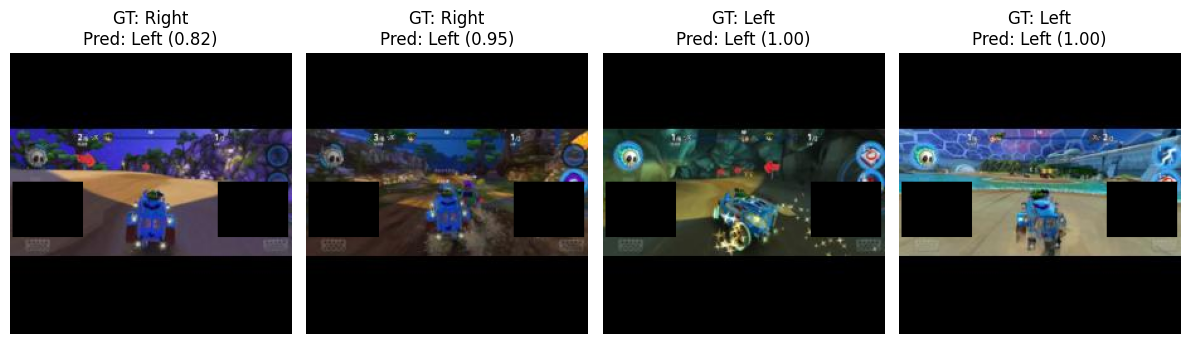

In [32]:
predict_and_visualize_from_datagen(
    model=model,
    datagen=val_gen,
    class_names=["Left", "None", "Right"],
    n=4,
)


In [60]:
import numpy as np
import tensorflow as tf
from collections import defaultdict


def compute_precision_recall(
    model,
    datagen,
    class_names,
):
    """
    Compute precision and recall for each class over the entire datagen.

    Args:
        model: trained tf.keras.Model (outputs logits)
        datagen: FrameCSVSequence
        class_names: list like ["Left", "None", "Right"]

    Returns:
        dict with per-class precision/recall/support
    """

    num_classes = len(class_names)

    # Confusion matrix counts
    tp = np.zeros(num_classes, dtype=np.int64)
    fp = np.zeros(num_classes, dtype=np.int64)
    fn = np.zeros(num_classes, dtype=np.int64)
    support = np.zeros(num_classes, dtype=np.int64)

    for i in range(len(datagen)):
        x, y_true = datagen[i]

        logits = model.predict(x, verbose=0)
        y_pred = np.argmax(tf.nn.softmax(logits, axis=-1).numpy(), axis=1)

        for c in range(num_classes):
            support[c] += np.sum(y_true == c)
            tp[c] += np.sum((y_pred == c) & (y_true == c))
            fp[c] += np.sum((y_pred == c) & (y_true != c))
            fn[c] += np.sum((y_pred != c) & (y_true == c))

    results = {}

    print("\nPrecision / Recall per class:")
    print("-" * 45)

    for c, name in enumerate(class_names):
        precision = tp[c] / (tp[c] + fp[c] + 1e-9)
        recall = tp[c] / (tp[c] + fn[c] + 1e-9)

        results[name] = {
            "precision": float(precision),
            "recall": float(recall),
            "support": int(support[c]),
        }

        print(
            f"{name:>5} | "
            f"precision: {precision:.4f} | "
            f"recall: {recall:.4f} | "
            f"support: {support[c]}"
        )

    macro_precision = np.mean([results[n]["precision"] for n in class_names])
    macro_recall = np.mean([results[n]["recall"] for n in class_names])

    print("-" * 45)
    print(f"Macro precision: {macro_precision:.4f}")
    print(f"Macro recall:    {macro_recall:.4f}")

    return results


In [61]:
class_names = ["Left", "None", "Right"]

metrics = compute_precision_recall(
    model=model,
    datagen=train_gen,
    class_names=class_names,
)



Precision / Recall per class:
---------------------------------------------
 Left | precision: 0.7486 | recall: 0.7422 | support: 11593
 None | precision: 0.0000 | recall: 0.0000 | support: 0
Right | precision: 0.6903 | recall: 0.6975 | support: 9550
---------------------------------------------
Macro precision: 0.4796
Macro recall:    0.4799
